In [ ]:
import pandas as pd

# load data
df = pd.read_csv("/content/drive/MyDrive/bootcamp dibimbing/Take home Test/Data Analyst/Zomato Dataset.csv")

# lihat 5 data teratas
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


# Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

##  2. cek missing value

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Delivery_person_Ratings,1908
Delivery_person_Age,1854
Time_Orderd,1731
City,1200
multiple_deliveries,993
Weather_conditions,616
Road_traffic_density,601
Festival,228
ID,0
Delivery_person_ID,0


In [ ]:
missing = df.isnull().sum()
percentage = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': percentage
}).sort_values(by='Percentage (%)', ascending=False)

missing_df

,Missing Count,Percentage (%)
Delivery_person_Ratings,1908,4.185679
Delivery_person_Age,1854,4.067217
Time_Orderd,1731,3.797385
City,1200,2.632503
multiple_deliveries,993,2.178396
Weather_conditions,616,1.351351
Road_traffic_density,601,1.318445
Festival,228,0.500176
ID,0,0.000000
Delivery_person_ID,0,0.000000


insight : Berdasarkan hasil eksplorasi data, terdapat beberapa kolom yang memiliki missing values, seperti Delivery_person_Age, Delivery_person_Ratings, dan multiple_deliveries.

Namun, persentase missing pada setiap kolom relatif kecil (kurang dari 5% dari total data), sehingga masih dapat ditangani dengan teknik imputasi tanpa mengurangi jumlah data secara signifikan.

Oleh karena itu, dipilih metode imputasi menggunakan median untuk variabel numerik dan modus untuk variabel kategorikal guna menjaga distribusi data tetap stabil.

## 3. cek duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

insight : Berdasarkan hasil pengecekan, tidak ditemukan data duplikat dalam dataset.

In [ ]:
# rename kolom typo
df.rename(columns={'Time_Orderd': 'Time_Ordered'}, inplace=True)

In [ ]:
# replace string 'NaN ' jadi NaN beneran
import numpy as np
df.replace('NaN ', np.nan, inplace=True)

## 4. Handle Missing Values

In [ ]:
# numerik →  median
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].median())

In [ ]:
# kategorikal → modus
cat_cols = ['Weather_conditions', 'Road_traffic_density', 'Festival', 'City']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
missing = df.isnull().sum()
percentage = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': percentage
}).sort_values(by='Percentage (%)', ascending=False)

missing_df

,Missing Count,Percentage (%)
Time_Ordered,1731,3.797385
ID,0,0.000000
Delivery_person_Age,0,0.000000
Delivery_person_ID,0,0.000000
Delivery_person_Ratings,0,0.000000
Restaurant_latitude,0,0.000000
Delivery_location_latitude,0,0.000000
Restaurant_longitude,0,0.000000
Delivery_location_longitude,0,0.000000
Order_Date,0,0.000000


In [ ]:
df = df.dropna(subset=['Time_Ordered'])

insight : Terdapat missing values pada variabel waktu pemesanan (Time_Ordered) sebesar 3.8%.oleh karena itu, maka dilakukan penghapusan baris yang memiliki nilai kosong untuk menjaga akurasi analisis Karena variabel ini krusial untuk perhitungan waktu persiapan.

In [ ]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Ordered,0


## 5. Cek Outlier

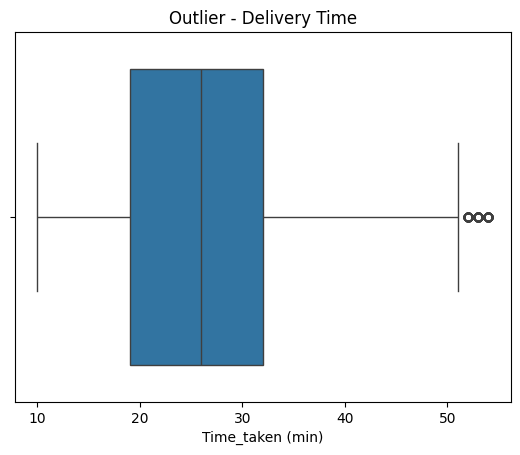

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x=df['Time_taken (min)'])
plt.title("Outlier - Delivery Time")
plt.show()

insight : ditemukan outlier sekitar 0.5% data. Namun, mengingat konteks operasional delivery, nilai tersebut masih berpotensi merepresentasikan kondisi nyata seperti kemacetan, cuaca buruk, atau tingginya permintaan.

Oleh karena itu, tidak seluruh outlier dihapus, melainkan hanya dilakukan filtering pada nilai yang tidak realistis untuk menjaga kualitas analisis.

In [ ]:
Q1 = df['Time_taken (min)'].quantile(0.25)
Q3 = df['Time_taken (min)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Time_taken (min)'] < lower_bound) |
              (df['Time_taken (min)'] > upper_bound)]

print("Jumlah outlier:", len(outliers))

Jumlah outlier: 255


In [ ]:
df = df[(df['Time_taken (min)'] > 5) & (df['Time_taken (min)'] < 120)]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Feature Engineering

## preparation time

In [ ]:
df['Time_Ordered'] = pd.to_datetime(df['Time_Ordered'], errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce')


In [ ]:
df = df.dropna(subset=['Time_Ordered','Time_Order_picked'])

In [ ]:
df[['Time_Ordered', 'Time_Order_picked']].head()

,Time_Ordered,Time_Order_picked
0,2026-04-10 21:55:00,2026-04-10 22:10:00
1,2026-04-10 14:55:00,2026-04-10 15:05:00
2,2026-04-10 17:30:00,2026-04-10 17:40:00
3,2026-04-10 09:20:00,2026-04-10 09:30:00
4,2026-04-10 19:50:00,2026-04-10 20:05:00


In [ ]:
# Menghitung pre-time
df['prep_time'] = (df['Time_Order_picked'] - df['Time_Ordered']).dt.total_seconds() / 60

In [ ]:
# Handle negatif (midnight case)

df['prep_time'] = df['prep_time'].apply(lambda x: x if x > 0 else x + 1440)

In [ ]:
df['prep_time'].describe()

,prep_time
count,35407.000000
mean,9.944926
std,4.086433
min,5.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,15.000000


insight : Waktu persiapan pesanan (prep_time) relatif stabil dengan rata-rata sekitar 10 menit.yang menunjukkan bahwa proses operasional di restoran cukup konsisten dan terstandarisasi. Maka, keterlambatan delivery kemungkinan besar disebabkan oleh faktor lain seperti jarak atau kondisi lalu lintas.

# Distance Calculation

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

df['distance_km'] = df.apply(lambda row: haversine(
    row['Restaurant_latitude'],
    row['Restaurant_longitude'],
    row['Delivery_location_latitude'],
    row['Delivery_location_longitude']
), axis=1)

# Filter distances
df = df[df['distance_km'] < 30]

In [ ]:
df['distance_category'] = pd.cut(
    df['distance_km'],
    bins=[0,2,5,10,20],
    labels=['Very Near','Near','Medium','Far']
)

Encoding

In [ ]:
'''from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'Weather_conditions',
    'Road_traffic_density',
    'Type_of_order',
    'Type_of_vehicle',
    'Festival',
    'City'
]

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))'''

"from sklearn.preprocessing import LabelEncoder\n\ncategorical_cols = [\n    'Weather_conditions',\n    'Road_traffic_density',\n    'Type_of_order',\n    'Type_of_vehicle',\n    'Festival',\n    'City'\n]\n\nle = LabelEncoder()\nfor col in categorical_cols:\n    df[col] = le.fit_transform(df[col].astype(str))"

# Eksplorasi Data (EDA)

## Distribusi Target (Time_taken)

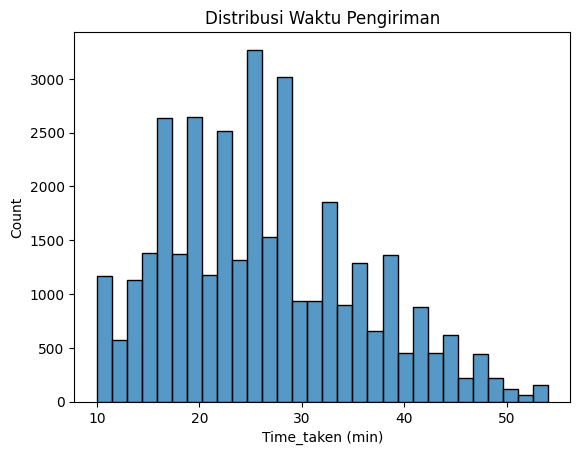

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(df['Time_taken (min)'], bins=30)
plt.title("Distribusi Waktu Pengiriman")
plt.show()


In [ ]:
df['Time_taken (min)'].describe()

,Time_taken (min)
count,35280.000000
mean,26.349546
std,9.398913
min,10.000000
25%,19.000000
50%,26.000000
75%,32.000000
max,54.000000


insight : rata rata waktu pengirimanan 20 - 30 menit

## Faktor paling berpengaruh

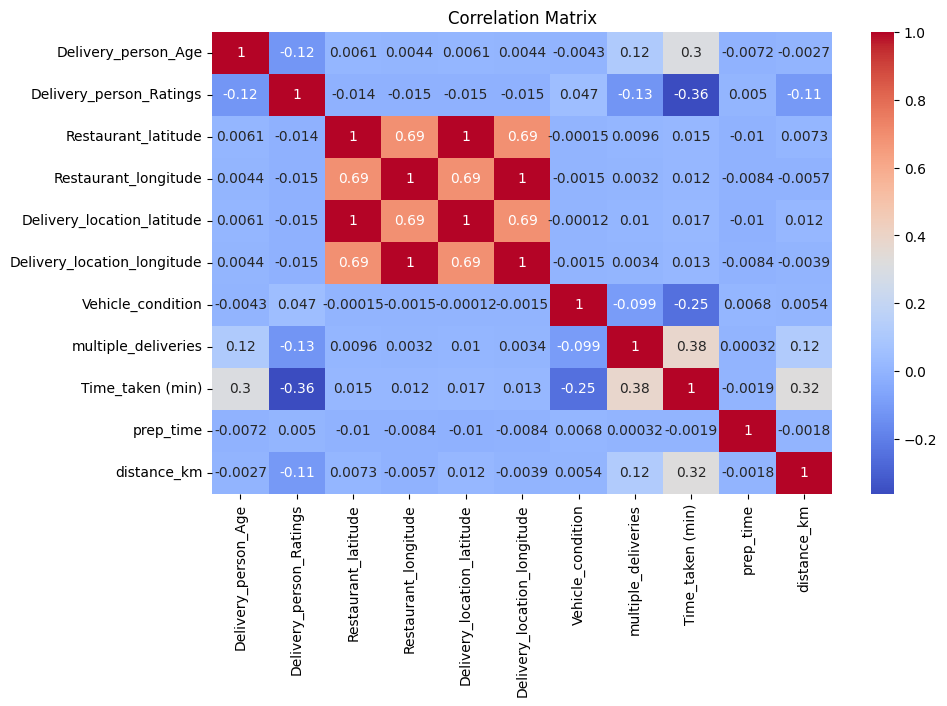

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

insight : Faktor utama yang mempengaruhi waktu pengiriman adalah jumlah pengiriman dalam satu perjalanan, performa delivery person (rating), serta kondisi operasional seperti festival dan kendaraan.

waktu persiapan makanan memiliki korelaso yang sangat kecil, sehingga keterlambatan lebih disebabkan oleh faktor distribusi dan logistik dibandingkan proses di restoran.

## Distance vs Delivery Time

/tmp/ipykernel_559/730882204.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_summary = df.groupby('distance_category')['Time_taken (min)'].mean().reset_index()


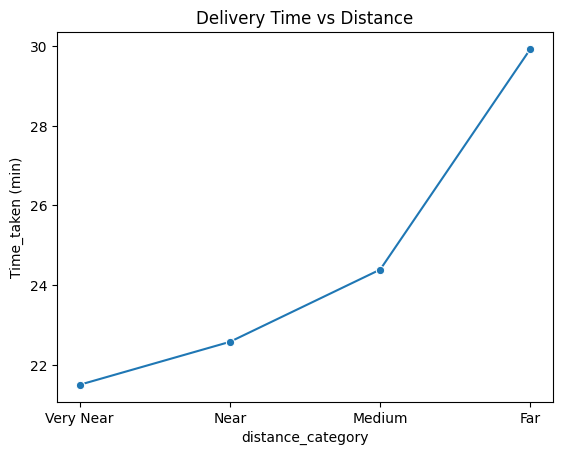

In [ ]:
distance_summary = df.groupby('distance_category')['Time_taken (min)'].mean().reset_index()

plt.figure()
sns.lineplot(data=distance_summary, x='distance_category', y='Time_taken (min)', marker='o')
plt.title("Delivery Time vs Distance")
plt.show()

In [ ]:
df['distance_category'] = pd.cut(
    df['distance_km'],
    bins=[0, 2, 5, 10, 20],
    labels=['Very Near', 'Near', 'Medium', 'Far']
)

df.groupby('distance_category')['Time_taken (min)'].agg(['mean', 'median', 'count'])

/tmp/ipykernel_559/591468355.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('distance_category')['Time_taken (min)'].agg(['mean', 'median', 'count'])


,mean,median,count
distance_category,,,
Very Near,21.496603,21.0,3238
Near,22.574289,22.0,6293
Medium,24.388959,25.0,9528
Far,29.931164,29.0,14600


insight : semakin jauh jarak pengiriman, semakin lama waktu yang dibutuhkan., menunjukkan bahwa jarak merupakan faktor utama dalam menentukan durasi pengiriman.

## Traffic vs Delivery Time

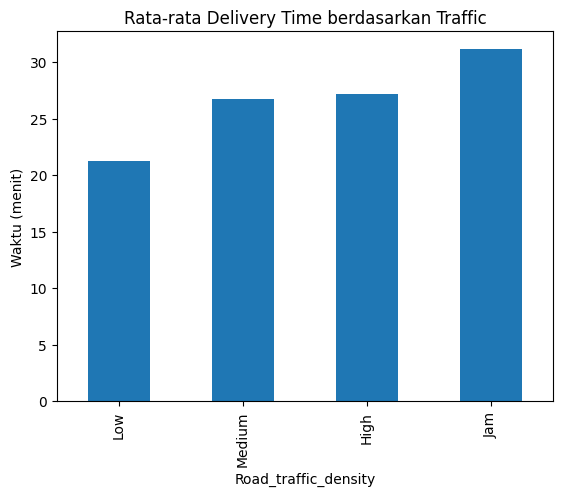

In [ ]:
traffic_summary = df.groupby('Road_traffic_density')['Time_taken (min)'].mean().sort_values()

traffic_summary.plot(kind='bar')
plt.title("Rata-rata Delivery Time berdasarkan Traffic")
plt.ylabel("Waktu (menit)")
plt.show()

In [ ]:
df.groupby('Road_traffic_density')['Time_taken (min)'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)

,mean,median,count
Road_traffic_density,,,
Jam,31.149369,31.0,11254
High,27.208479,27.0,3444
Medium,26.741464,27.0,8757
Low,21.241099,20.0,11825


insight : Kondisi lalu lintas yang lebih padat menyebabkan peningkatan waktu pengiriman, menunjukkan bahwa traffic menjadi salah satu faktor eksternal utama yang mempengaruhi keterlambatan.

## Weather vs Delivery Time

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

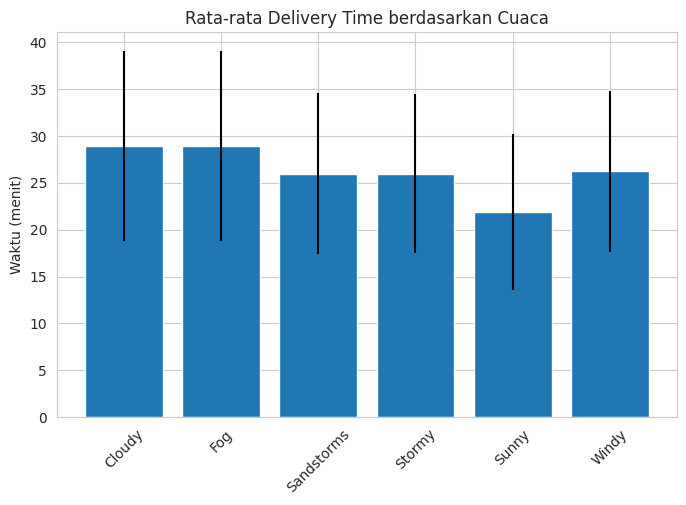

In [ ]:
weather_summary = df.groupby('Weather_conditions')['Time_taken (min)'].agg(['mean','std']).reset_index()

plt.figure()
plt.bar(weather_summary['Weather_conditions'], weather_summary['mean'], yerr=weather_summary['std'])
plt.xticks(rotation=45)
plt.title("Rata-rata Delivery Time berdasarkan Cuaca")
plt.ylabel("Waktu (menit)")
plt.show()

In [ ]:
df.groupby('Weather_conditions')['Time_taken (min)'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)

,mean,median,count
Weather_conditions,,,
Fog,28.958739,28.0,5962
Cloudy,28.949590,29.0,5852
Windy,26.229199,26.0,5877
Stormy,25.994461,26.0,5958
Sandstorms,25.988418,26.0,5871
Sunny,21.865451,20.0,5760


insight : cuaca cerah menjadi faktor pengiriman semakin cepat, dan sebaliknya jika cuaca buruk, berangin, atau berapan maka pengirman menjadi lebih lama. Hal ini karena fator cuaca mempangurhi lama pengiriman

insight : Cuaca buruk cenderung meningkatkan waktu delivery dibandingkan kondisi normal, serta meningkatkan variasi waktu pengiriman.

## Multiple Deliveries

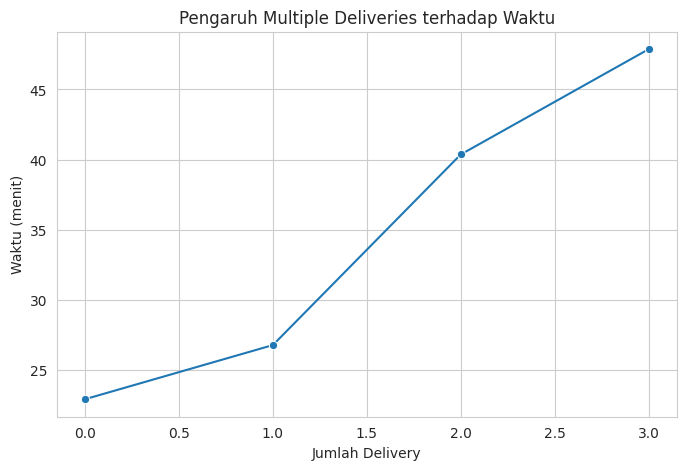

In [ ]:
multi_summary = df.groupby('multiple_deliveries')['Time_taken (min)'].mean().reset_index()

plt.figure()
sns.lineplot(data=multi_summary, x='multiple_deliveries', y='Time_taken (min)', marker='o')
plt.title("Pengaruh Multiple Deliveries terhadap Waktu")
plt.xlabel("Jumlah Delivery")
plt.ylabel("Waktu (menit)")
plt.show()


In [ ]:
df.groupby('multiple_deliveries')['Time_taken (min)'].agg(['mean', 'median', 'count'])

,mean,median,count
multiple_deliveries,,,
0.0,22.914929,22.0,10932
1.0,26.774000,26.0,22500
2.0,40.362245,40.0,1568
3.0,47.867857,48.0,280


insight : Semakin banyak pengiriman dalam satu perjalanan, semakin lama waktu delivery, akibat meningkatnya kompleksitas rute dan jumlah pemberhentian.

## Driver Performance (Rating)

In [ ]:
df['rating_category'] = pd.cut(
    df['Delivery_person_Ratings'],
    bins=[0, 3, 4, 5],
    labels=['Low', 'Medium', 'High']
)

df.groupby('rating_category')['Time_taken (min)'].mean()

/tmp/ipykernel_559/2352314624.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rating_category')['Time_taken (min)'].mean()


,Time_taken (min)
rating_category,
Low,37.123457
Medium,36.112714
High,25.774957


/tmp/ipykernel_559/3384392703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_summary = df.groupby('rating_category')['Time_taken (min)'].mean().reset_index()


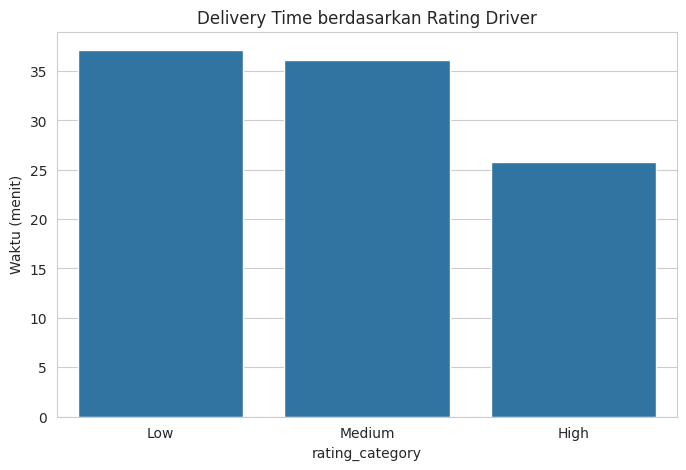

In [ ]:
rating_summary = df.groupby('rating_category')['Time_taken (min)'].mean().reset_index()

plt.figure()
sns.barplot(data=rating_summary, x='rating_category', y='Time_taken (min)')
plt.title("Delivery Time berdasarkan Rating Driver")
plt.ylabel("Waktu (menit)")
plt.show()

insight : Driver yang rating lebih tinggi cenderung memiliki waktu pengiriman yang lebih cepat, hal ini menunjukkan bahwa performa individu berpengaruh terhadap efisiensi delivery.

## Vehicle Condition

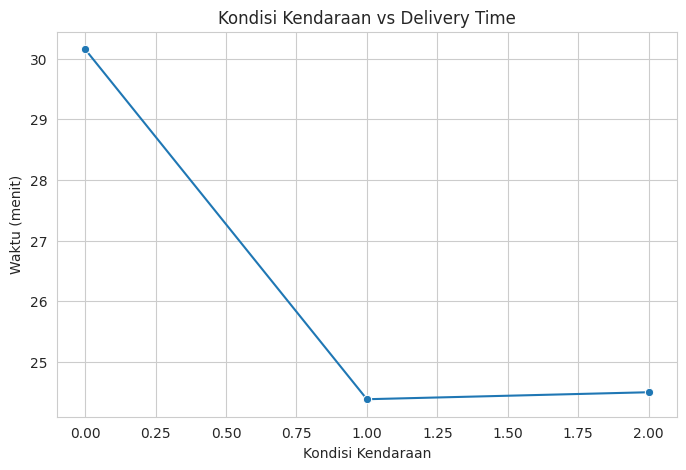

In [ ]:
vehicle_summary = df.groupby('Vehicle_condition')['Time_taken (min)'].mean().reset_index()

plt.figure()
sns.lineplot(data=vehicle_summary, x='Vehicle_condition', y='Time_taken (min)', marker='o')
plt.title("Kondisi Kendaraan vs Delivery Time")
plt.xlabel("Kondisi Kendaraan")
plt.ylabel("Waktu (menit)")
plt.show()

In [ ]:
df.groupby('Vehicle_condition')['Time_taken (min)'].mean()

,Time_taken (min)
Vehicle_condition,
0,30.155303
1,24.384923
2,24.500043


insigt : Kendaraan yang memilikik kondisi lebih baik dapat mendukung waktu pengiriman yang lebih cepat, sehingga kualitas kendaraan berperan dalam kelancaran operasional.

## Festival Impact

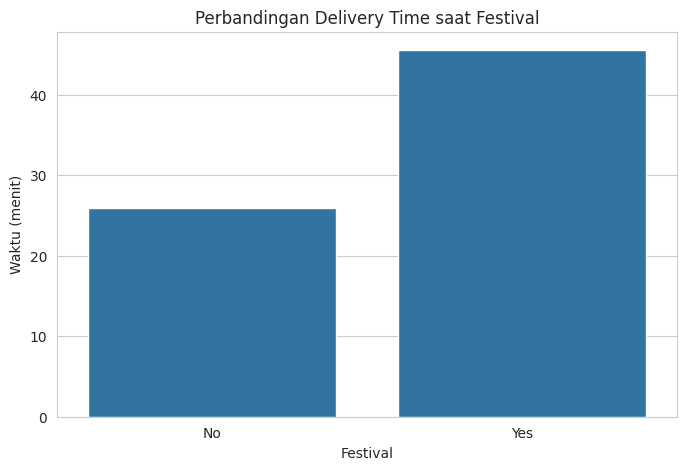

In [ ]:
festival_summary = df.groupby('Festival')['Time_taken (min)'].mean().reset_index()

plt.figure()
sns.barplot(data=festival_summary, x='Festival', y='Time_taken (min)')
plt.title("Perbandingan Delivery Time saat Festival")
plt.ylabel("Waktu (menit)")
plt.show()

In [ ]:
df.groupby('Festival')['Time_taken (min)'].mean()

,Time_taken (min)
Festival,
No,25.962959
Yes,45.530846


insight : Waktu pengiriman meningkat saat periode festival, kemungkinan disebabkan oleh lonjakan permintaan dan kepadatan lalu lintas.

## Pola berdasarkan waktu

In [ ]:
df['order_hour'] = df['Time_Ordered'].dt.hour

df.groupby('order_hour')['Time_taken (min)'].mean()

,Time_taken (min)
order_hour,
8,19.606173
9,19.544529
10,19.498162
11,27.118912
12,26.581470
13,27.591276
14,27.689320
15,22.884892
16,22.991525


insght semakin lama (jam semkin sibuk) maka deliveri semakin lama

## Pola berdasarkan kota

In [ ]:
df.groupby('City')['Time_taken (min)'].mean().sort_values()

,Time_taken (min)
City,
Urban,22.932244
Metropolitian,27.214194
Semi-Urban,49.661765


insight : Semi-Urban memiliki waktu pengiriman hampir 2x lebih lama dibanding kota lainnya, yang mengindikasikan adanya permasalahan operasional atau karakteristik wilayah yang berbeda.

## Pola berdasarkan jenis order

In [ ]:
df.groupby('Type_of_order')['Time_taken (min)'].mean()

,Time_taken (min)
Type_of_order,
Buffet,26.305264
Drinks,26.300600
Meal,26.487327
Snack,26.304640


insight : Tidak terdapat perbedaan signifikan waktu pengiriman berdasarkan jenis order, karena rata-rata waktu delivery di semua kategori berada di kisaran yang sama (~26 menit).

In [ ]:
df_clean = df.copy()

# Regression (prediksi waktu)

### **IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df_model = df_clean.copy()
df_model

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Ordered,...,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),prep_time,distance_km,distance_category,rating_category,order_hour
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,2026-04-10 21:55:00,...,motorcycle,3.0,No,Metropolitian,46,15.0,10.280582,Far,High,21
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,2026-04-10 14:55:00,...,motorcycle,1.0,No,Metropolitian,23,10.0,6.242319,Medium,High,14
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,2026-04-10 17:30:00,...,scooter,1.0,No,Metropolitian,21,10.0,13.787860,Far,High,17
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,2026-04-10 09:20:00,...,motorcycle,0.0,No,Metropolitian,20,10.0,2.930258,Near,High,9
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,2026-04-10 19:50:00,...,scooter,1.0,No,Metropolitian,41,15.0,19.396618,Far,High,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45578,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,08-03-2022,2026-04-10 21:45:00,...,motorcycle,1.0,No,Metropolitian,33,10.0,16.600272,Far,High,21
45579,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,2026-04-10 11:35:00,...,motorcycle,0.0,No,Metropolitian,32,10.0,1.489846,Very Near,High,11
45580,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,2026-04-10 19:55:00,...,motorcycle,1.0,No,Metropolitian,36,15.0,11.007735,Far,High,19
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,2026-04-10 13:35:00,...,motorcycle,1.0,No,Metropolitian,26,5.0,6.232393,Medium,High,13


## drop kolom yang tidak relevan

In [ ]:
drop_cols = [
    'ID', 'Delivery_person_ID',
    'Order_Date', 'Time_Ordered', 'Time_Order_picked'
]

df_model = df_model.drop(columns=drop_cols)

## target

In [ ]:
y = df_model['Time_taken (min)']
X = df_model.drop('Time_taken (min)', axis=1)

## split data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## encoding

In [ ]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns

encoder = OneHotEncoder(
    sparse_output=False,
    drop='first',
    handle_unknown='ignore'
)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

## Scalling

In [ ]:
scaler = StandardScaler()

X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

In [ ]:
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

print("Final shape:", X_train_final.shape)

Final shape: (28224, 33)


## Modeling

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print(f"\n=== {name} ===")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)


=== Linear Regression ===
MAE: 4.634869716220655
RMSE: 5.806934763650569
R2: 0.6151914471184896

=== Random Forest ===
MAE: 3.137606292517007
RMSE: 3.914661682862242
R2: 0.8251203433508778


## hasil

In [ ]:
results_df = pd.DataFrame(results).T
print(results_df)

                        MAE      RMSE        R2
Linear Regression  4.634870  5.806935  0.615191
Random Forest      3.137606  3.914662  0.825120


## Visualisasi

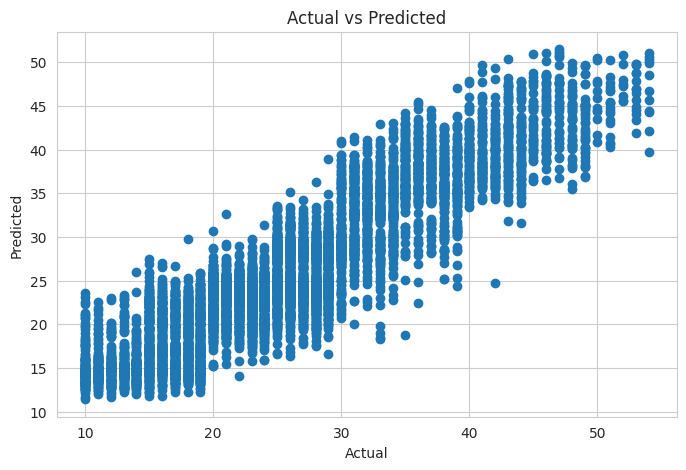

In [ ]:
best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train_final, y_train)
y_pred = best_model.predict(X_test_final)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## CROSS VALIDATION (K-FOLD)

In [ ]:
cv_scores = cross_val_score(
    best_model,
    X_train_final,
    y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-cv_scores)

print("CV RMSE:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

CV RMSE: [3.87520571 3.94498353 3.89819526 3.98827505 3.98785141]
Mean RMSE: 3.938902191028903


## Hyperparameter

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_final, y_train)

print("Best Params:", grid.best_params_)

best_rf = grid.best_estimator_


Best Params: {'max_depth': None, 'n_estimators': 200}


In [ ]:
y_pred_tuned = best_rf.predict(X_test_final)

print("\n=== Tuned Model ===")
print("MAE:", mean_absolute_error(y_test, y_pred_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("R2:", r2_score(y_test, y_pred_tuned))


=== Tuned Model ===
MAE: 3.131941609977324
RMSE: 3.90260123873442
R2: 0.8261962357568731


In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest (Before)', 'Random Forest (After)'],
    'MAE': [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_tuned)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_tuned ))
    ],
    'R2': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_tuned)
    ]
})

print("=== Model Comparison ===")
print(comparison_df)

=== Model Comparison ===
                    Model       MAE      RMSE        R2
0  Random Forest (Before)  3.137606  3.914662  0.825120
1   Random Forest (After)  3.131942  3.902601  0.826196


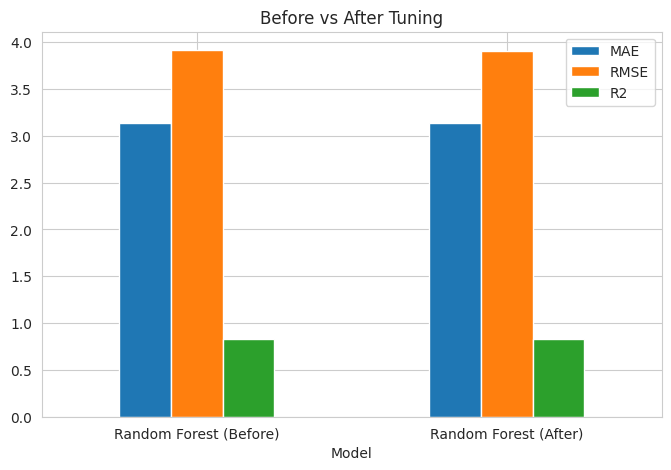

In [ ]:
comparison_df.set_index('Model')[['MAE','RMSE','R2']].plot(kind='bar')
plt.title('Before vs After Tuning')
plt.xticks(rotation=0)
plt.show()

Feature Importance

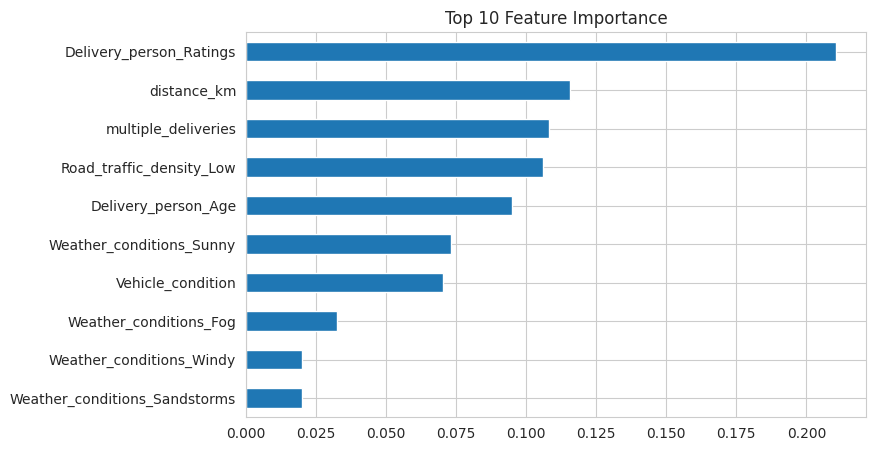

In [ ]:
importances = best_rf.feature_importances_
feature_names = X_train_final.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure()
feat_imp.plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Save Model

In [ ]:
import joblib

# Save the best performing model
joblib.dump(best_rf, 'best_random_forest_model.joblib')

print("Model saved as 'best_random_forest_model.joblib'")

Model saved as 'best_random_forest_model.joblib'


In [ ]:
import pickle

# Save the best performing model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print("Model saved as 'best_model.pkl'")

Model saved as 'best_model.pkl'


In [ ]:
with open("features.pkl", "wb") as f:
    pickle.dump(X_train_final.columns.tolist(), f)